In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadwaqas023/predictive-maintenance-oil-and-gas-pipeline-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predictive-maintenance-oil-and-gas-pipeline-data' dataset.
Path to dataset files: /kaggle/input/predictive-maintenance-oil-and-gas-pipeline-data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os

print(os.listdir(path))

['market_pipe_thickness_loss_dataset.csv']


In [ ]:
df = pd.read_csv(f"{path}/market_pipe_thickness_loss_dataset.csv")

df.head()

,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,ASTM A333 Grade 6,300,84.9,16.04,4.91,31.72,2,Moderate
1,800,22.00,PVC,ASTM A106 Grade B,150,14.1,7.38,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,API 5L X52,2500,0.6,2.12,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,API 5L X42,1500,52.7,5.58,6.20,16.01,19,Critical
4,1500,24.32,HDPE,API 5L X65,1500,11.7,12.29,8.58,35.28,20,Critical


In [ ]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1000, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pipe_Size_mm              1000 non-null   int64  
 1   Thickness_mm              1000 non-null   float64
 2   Material                  1000 non-null   object 
 3   Grade                     1000 non-null   object 
 4   Max_Pressure_psi          1000 non-null   int64  
 5   Temperature_C             1000 non-null   float64
 6   Corrosion_Impact_Percent  1000 non-null   float64
 7   Thickness_Loss_mm         1000 non-null   float64
 8   Material_Loss_Percent     1000 non-null   float64
 9   Time_Years                1000 non-null   int64  
 10  Condition                 1000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 86.1+ KB


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.describe()

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,522.000000,16.073530,1004.100000,42.595600,9.745990,4.886300,46.747560,12.961000
std,443.703587,10.548358,812.843099,41.127071,5.817492,2.901123,46.602553,7.135993
min,50.000000,3.000000,150.000000,-50.000000,0.000000,0.010000,0.080000,1.000000
25%,150.000000,7.357500,300.000000,13.400000,4.492500,2.365000,15.665000,7.000000
50%,300.000000,12.930000,900.000000,41.200000,9.720000,4.915000,31.660000,13.000000
75%,800.000000,23.027500,1500.000000,69.150000,14.832500,7.432500,61.035000,19.000000
max,1500.000000,49.530000,2500.000000,149.700000,20.000000,9.990000,318.750000,25.000000


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['pipe_size_mm', 'thickness_mm', 'material', 'grade', 'max_pressure_psi',
       'temperature_c', 'corrosion_impact_percent', 'thickness_loss_mm',
       'material_loss_percent', 'time_years', 'condition'],
      dtype='object')


##**EDA**

/tmp/ipykernel_3000/4093324653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='condition', data=df, palette='Greens')


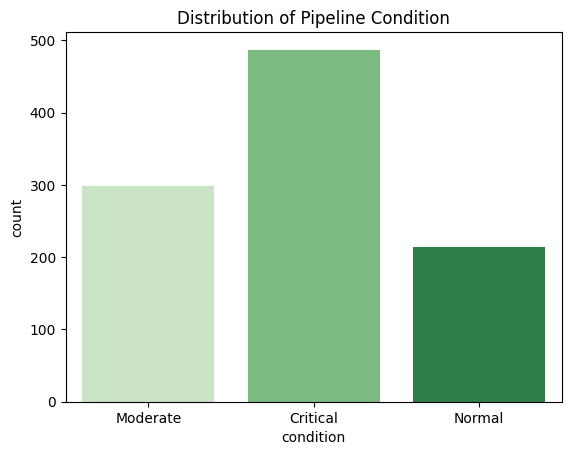

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='condition', data=df, palette='Greens')
plt.title("Distribution of Pipeline Condition")
plt.show()

This plot shows the distribution of pipeline conditions in the dataset. The Critical class has the highest number of samples, followed by Moderate, while Normal has the lowest.

This imbalance is important because the machine learning model may become biased toward predicting the Critical class more frequently. As a result, the model may perform well on the majority class but struggle to accurately predict minority classes such as Normal.

Since the goal of this project is to accurately classify pipeline conditions, handling this imbalance is essential to ensure reliable predictions across all classes.

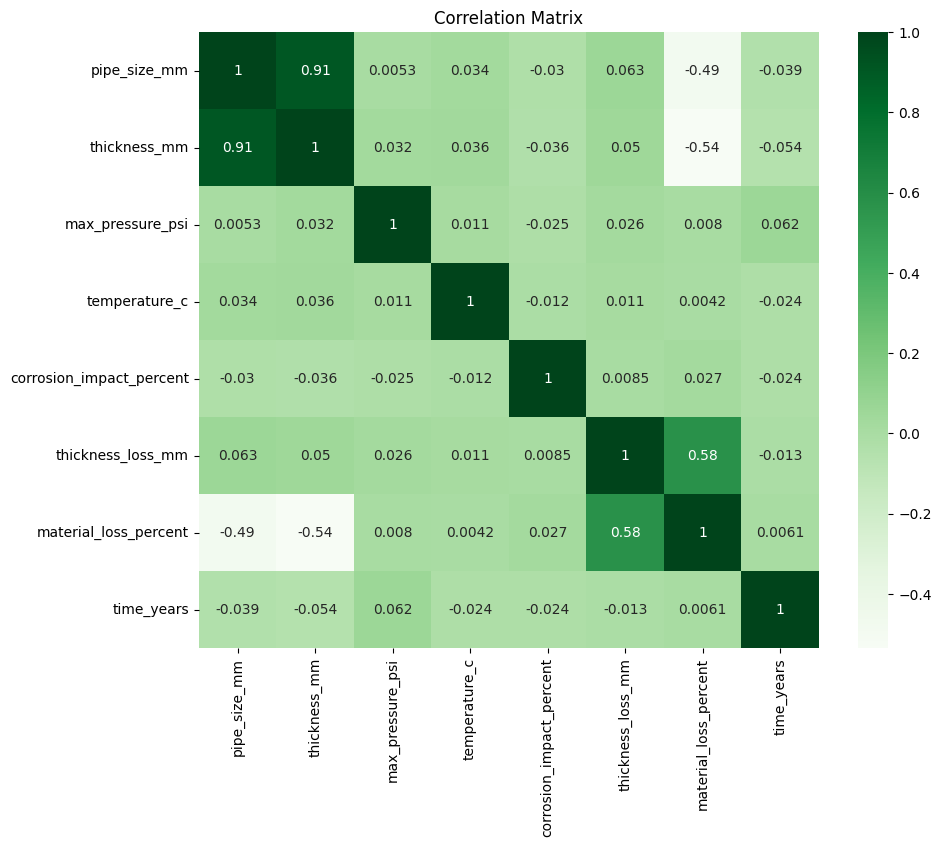

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows the relationships between numerical features in the dataset. Strong positive correlations are observed between pipe_size_mm and thickness_mm (≈ 0.91), indicating that larger pipes tend to have greater thickness.

Additionally, a moderate correlation exists between thickness_loss_mm and material_loss_percent (≈ 0.58), suggesting that these features represent related aspects of pipeline degradation.

These correlations indicate potential multicollinearity, where multiple features provide similar information. To address this, a new feature called degradation_score was created by combining related degradation indicators, which helps simplify the model and reduce redundancy.

Understanding these relationships is important for improving model performance and ensuring that the model does not rely on duplicated information.

/tmp/ipykernel_3000/375125116.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y='corrosion_impact_percent', data=df, palette='Greens')


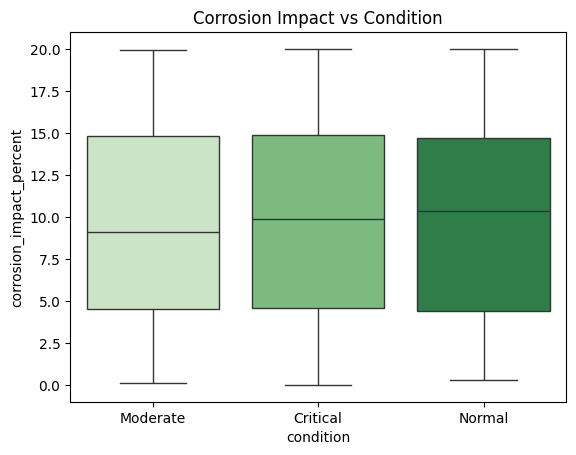

In [ ]:
sns.boxplot(x='condition', y='corrosion_impact_percent', data=df, palette='Greens')
plt.title("Corrosion Impact vs Condition")
plt.show()

/tmp/ipykernel_3000/1733203645.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y='max_pressure_psi', data=df, palette='Greens')


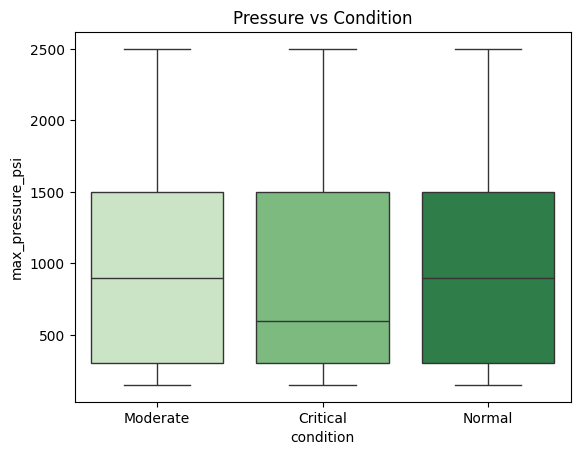

In [ ]:
sns.boxplot(x='condition', y='max_pressure_psi', data=df, palette='Greens')
plt.title("Pressure vs Condition")
plt.show()

/tmp/ipykernel_3000/3817096246.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y='temperature_c', data=df, palette='Greens')


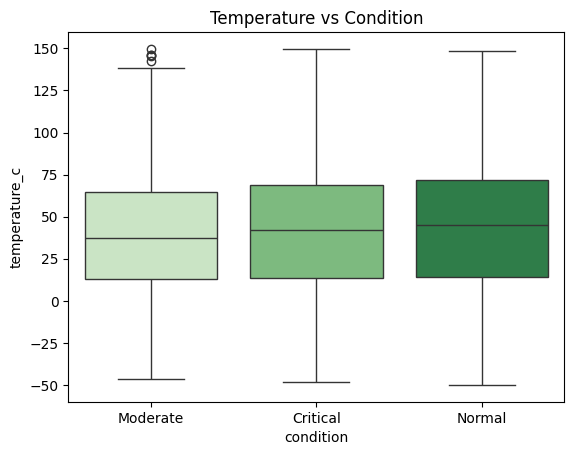

In [ ]:
sns.boxplot(x='condition', y='temperature_c', data=df, palette='Greens')
plt.title("Temperature vs Condition")
plt.show()

Overall, the boxplots show that individual features such as corrosion, pressure, and temperature do not clearly separate the pipeline conditions. This highlights the importance of combining multiple features, as done in the feature engineering step, to improve the model's ability to distinguish between different pipeline states.

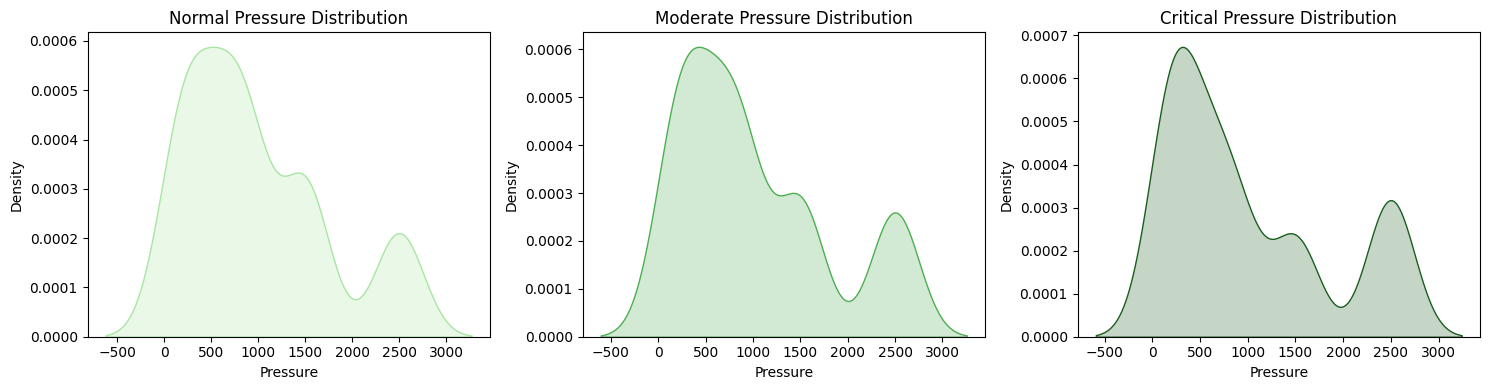

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

conditions = ['Normal', 'Moderate', 'Critical']
colors = ['#a8e6a3', '#4caf50', '#1b5e20']

plt.figure(figsize=(15,4))

for i, cond in enumerate(conditions):
    plt.subplot(1, 3, i+1)

    sns.kdeplot(
        data=df[df['condition'] == cond],
        x='max_pressure_psi',
        fill=True,
        color=colors[i]
    )

    plt.title(f"{cond} Pressure Distribution")
    plt.xlabel("Pressure")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

The separate KDE plots show that the pressure distribution is very similar across Normal, Moderate, and Critical pipeline conditions. All classes exhibit similar patterns and overlapping ranges, indicating no clear separation between them.

This suggests that pressure alone is not a strong feature for distinguishing pipeline conditions. However, it may still contribute when combined with other variables in the model.

These findings support the use of feature engineering to combine multiple factors, improving the model’s ability to detect complex patterns.

## **Feature** **Engineering**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pipe_size_mm              1000 non-null   int64  
 1   thickness_mm              1000 non-null   float64
 2   material                  1000 non-null   object 
 3   grade                     1000 non-null   object 
 4   max_pressure_psi          1000 non-null   int64  
 5   temperature_c             1000 non-null   float64
 6   corrosion_impact_percent  1000 non-null   float64
 7   thickness_loss_mm         1000 non-null   float64
 8   material_loss_percent     1000 non-null   float64
 9   time_years                1000 non-null   int64  
 10  condition                 1000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 86.1+ KB


In [ ]:
dfe= df.copy()
## Creating new fetaures to imporve models accuracy.
# 1. Remaining wall percentage
dfe['Thickness_Remaining_Pct'] = ((dfe['thickness_mm'] - dfe['thickness_loss_mm']) / dfe['thickness_mm']) * 100

# 2. Annualised corrosion rate
dfe['Corrosion_Rate_Per_Year'] = dfe['thickness_loss_mm'] / dfe['time_years']

# 3. Pressure-to-thickness ratio (mechanical stress indicator)
dfe['Pressure_Per_Thickness'] = dfe['max_pressure_psi'] / dfe['thickness_mm']

# 4. Loss ratio (how effectively corrosion translates to material loss)
dfe['Loss_Ratio'] = dfe['material_loss_percent'] / (dfe['corrosion_impact_percent'] + 1)

# 5. Wall-to-diameter ratio (structural robustness)
dfe['Pipe_Wall_Ratio'] = dfe['thickness_mm'] / dfe['pipe_size_mm']


In [ ]:
## Encode Categorical columns

from sklearn.preprocessing import LabelEncoder, StandardScaler
le=LabelEncoder()
dfe['Material_Enc']  = le.fit_transform(dfe['material'])
dfe['Grade_Enc']     = le.fit_transform(dfe['grade'])
dfe['Condition_Enc'] = le.fit_transform(dfe['condition'])

# Apply Label Encoding to the target variable (condition)
# This converts categorical labels (e.g., Normal, Moderate, Critical)
# into numerical values (e.g., 0, 1, 2) so the model can process them.


In [ ]:
## df shape after adding features
print("database shape: ", dfe.shape)
dfe.describe()

database shape:  (1000, 19)


,pipe_size_mm,thickness_mm,max_pressure_psi,temperature_c,corrosion_impact_percent,thickness_loss_mm,material_loss_percent,time_years,Thickness_Remaining_Pct,Corrosion_Rate_Per_Year,Pressure_Per_Thickness,Loss_Ratio,Pipe_Wall_Ratio,Material_Enc,Grade_Enc,Condition_Enc
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,522.000000,16.073530,1004.100000,42.595600,9.745990,4.886300,46.747560,12.961000,53.252472,0.756161,96.820558,7.234560,0.042168,1.94900,2.105000,0.727000
std,443.703587,10.548358,812.843099,41.127071,5.817492,2.901123,46.602553,7.135993,46.602587,1.259606,114.418950,11.713928,0.020791,1.43124,1.431791,0.791895
min,50.000000,3.000000,150.000000,-50.000000,0.000000,0.010000,0.080000,1.000000,-218.750000,0.000476,3.028468,0.006400,0.014100,0.00000,0.000000,0.000000
25%,150.000000,7.357500,300.000000,13.400000,4.492500,2.365000,15.665000,7.000000,38.963842,0.177679,23.246898,1.517060,0.027543,1.00000,1.000000,0.000000
50%,300.000000,12.930000,900.000000,41.200000,9.720000,4.915000,31.660000,13.000000,68.342564,0.373462,52.747508,3.511589,0.037456,2.00000,2.000000,1.000000
75%,800.000000,23.027500,1500.000000,69.150000,14.832500,7.432500,61.035000,19.000000,84.336331,0.735962,126.716370,7.684251,0.050910,3.00000,3.000000,1.000000
max,1500.000000,49.530000,2500.000000,149.700000,20.000000,9.990000,318.750000,25.000000,99.922780,9.750000,833.333333,121.367188,0.119800,4.00000,4.000000,2.000000


Preprocessing

In [ ]:
dfe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pipe_size_mm              1000 non-null   int64  
 1   thickness_mm              1000 non-null   float64
 2   material                  1000 non-null   object 
 3   grade                     1000 non-null   object 
 4   max_pressure_psi          1000 non-null   int64  
 5   temperature_c             1000 non-null   float64
 6   corrosion_impact_percent  1000 non-null   float64
 7   thickness_loss_mm         1000 non-null   float64
 8   material_loss_percent     1000 non-null   float64
 9   time_years                1000 non-null   int64  
 10  condition                 1000 non-null   object 
 11  Thickness_Remaining_Pct   1000 non-null   float64
 12  Corrosion_Rate_Per_Year   1000 non-null   float64
 13  Pressure_Per_Thickness    1000 non-null   float64
 14  Loss_Rati

In [ ]:
# Separate input features (X) and target variable (y)
# Removed leakage-related features to ensure realistic model performance

Feature_cols = [

    'pipe_size_mm', 'thickness_mm', 'max_pressure_psi', 'temperature_c',
    'time_years',
    'Material_Enc', 'Grade_Enc',

    # Engineered features (keep if they don't directly leak target info)
    'Thickness_Remaining_Pct',
    'Corrosion_Rate_Per_Year',
    'Pressure_Per_Thickness',
    'Loss_Ratio',
    'Pipe_Wall_Ratio',
]

X = dfe[Feature_cols].values

# Target variable: pipeline condition (encoded as numbers)
y = dfe['Condition_Enc'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y,random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
## Stratified Cross-Validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## First model Random Forest

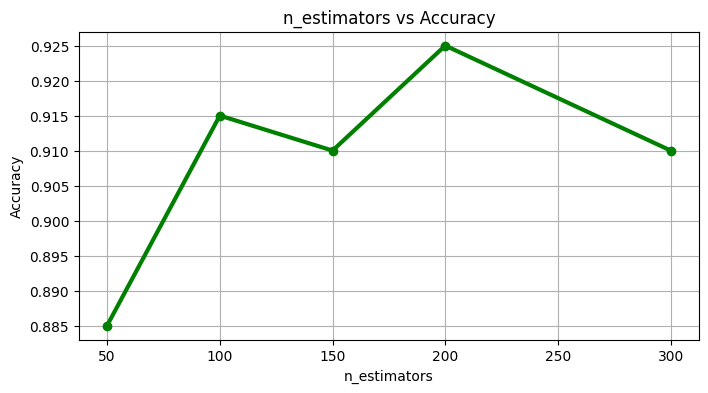

In [ ]:
tree_values = [50, 100, 150, 200, 300]

tree_accuracy = []

for n in tree_values:

    model = RandomForestClassifier(

        n_estimators=n,

        max_depth=None,

        min_samples_split=4,

        min_samples_leaf=1,

        class_weight='balanced',

        random_state=42,

        n_jobs=-1

    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    tree_accuracy.append(acc)

plt.figure(figsize=(8,4))

plt.plot(tree_values, tree_accuracy, marker='o', linewidth=3, color="green")

plt.title("n_estimators vs Accuracy")

plt.xlabel("n_estimators")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

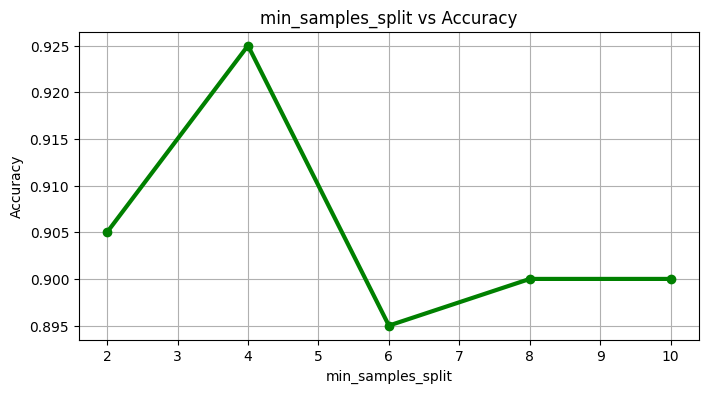

In [ ]:
split_values = [2, 4, 6, 8, 10]

split_accuracy = []

for split in split_values:

    model = RandomForestClassifier(

        n_estimators=200,

        max_depth=None,

        min_samples_split=split,

        min_samples_leaf=1,

        class_weight='balanced',

        random_state=42,

        n_jobs=-1

    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    split_accuracy.append(acc)

plt.figure(figsize=(8,4))

plt.plot(split_values, split_accuracy, marker='o', linewidth=3, color="green")

plt.title("min_samples_split vs Accuracy")

plt.xlabel("min_samples_split")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

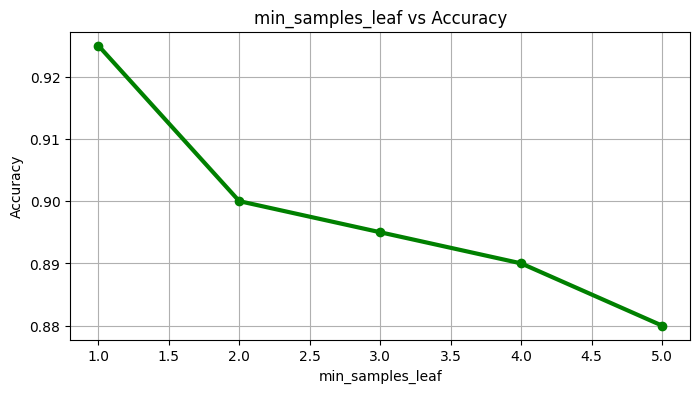

In [ ]:
leaf_values = [1, 2, 3, 4, 5]

leaf_accuracy = []

for leaf in leaf_values:

    model = RandomForestClassifier(

        n_estimators=200,

        max_depth=None,

        min_samples_split=4,

        min_samples_leaf=leaf,

        class_weight='balanced',

        random_state=42,

        n_jobs=-1

    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    leaf_accuracy.append(acc)

plt.figure(figsize=(8,4))

plt.plot(leaf_values, leaf_accuracy, marker='o', linewidth=3, color="green")

plt.title("min_samples_leaf vs Accuracy")

plt.xlabel("min_samples_leaf")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()


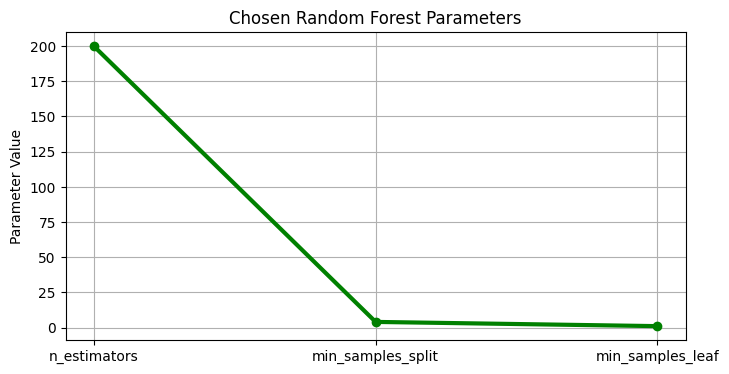

In [ ]:
parameters = [

    'n_estimators',

    'min_samples_split',

    'min_samples_leaf'

]

values = [

    200,

    4,

    1

]

plt.figure(figsize=(8,4))

plt.plot(parameters, values, marker='o', linewidth=3, color="green")

plt.title("Chosen Random Forest Parameters")

plt.ylabel("Parameter Value")

plt.grid(True)

plt.show()



In [ ]:
# Initialize Random Forest model
# Random Forest is chosen because it can handle complex, non-linear relationships
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
# cross validation
scores = cross_val_score(rf, X_train, y_train, cv=skf)
print('CV Acc: ', scores.mean())

# Train the model using training data
rf.fit(X_train, y_train)

CV Acc:  0.8887499999999999


RandomForestClassifier(class_weight='balanced', min_samples_split=4,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# Predict on test data
y_pred = rf.predict(X_test)

In [ ]:
# Evaluate model performance using multiple metrics:
# - Accuracy: overall correctness
# - Classification Report: precision, recall, f1-score for each class
# - Confusion Matrix: shows correct vs incorrect predictions

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94        97
           1       0.89      0.85      0.87        60
           2       1.00      0.93      0.96        43

    accuracy                           0.93       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.93      0.93      0.92       200


Confusion Matrix:
 [[94  3  0]
 [ 9 51  0]
 [ 0  3 40]]


In [ ]:
# Accuracy on training data
train_acc = rf.score(X_train, y_train)

# Accuracy on test data
test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.925


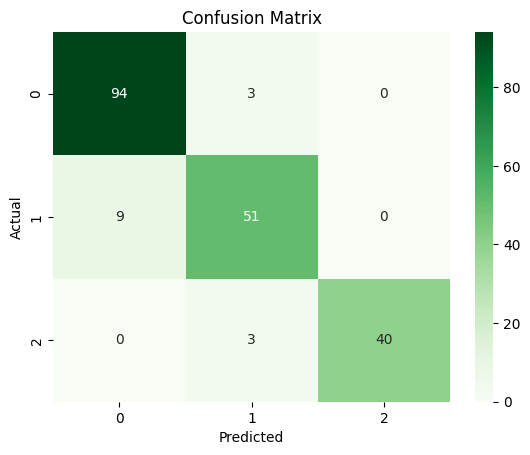

In [ ]:
# Visualize confusion matrix using heatmap for better interpretation
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

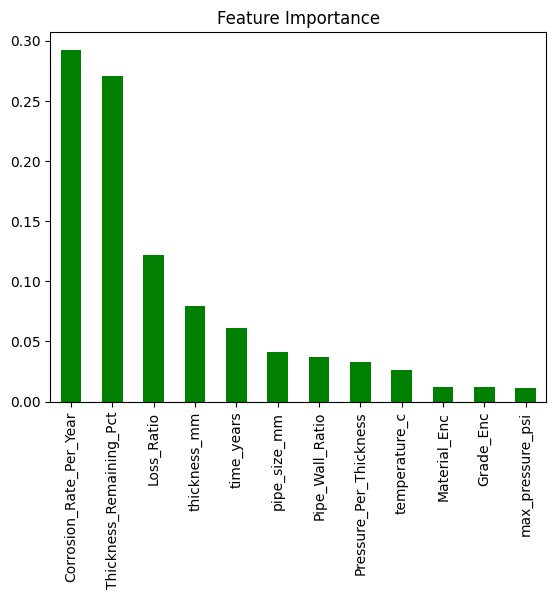

In [ ]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=Feature_cols).sort_values(ascending=False)

feat_imp.plot(kind='bar', color='green')
plt.title("Feature Importance")
plt.show()

## Second model SVM

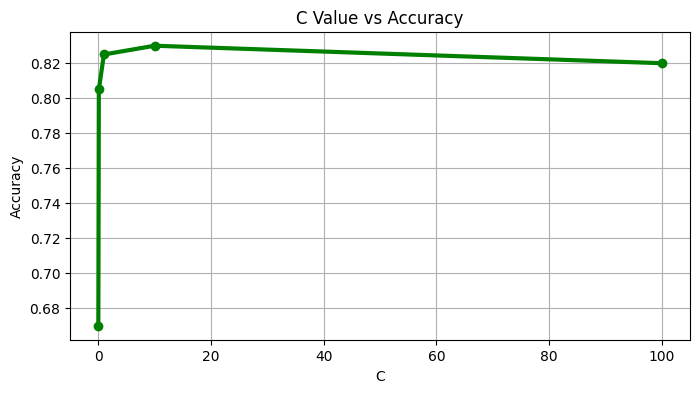

In [ ]:
c_values = [0.01, 0.1, 1, 10, 100]
c_accuracy = []

for c in c_values:

    model = SVC(
        kernel='linear',
        C=c,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    c_accuracy.append(acc)

plt.figure(figsize=(8,4))

plt.plot(c_values, c_accuracy, marker='o', linewidth=3, color="green")

plt.title("C Value vs Accuracy")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

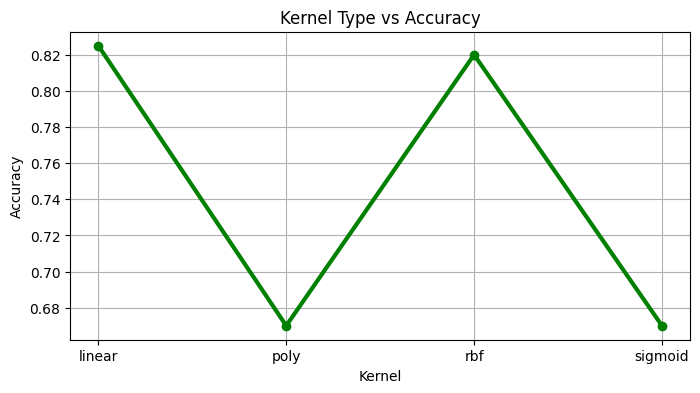

In [ ]:
kernel_values = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_accuracy = []

for kernel in kernel_values:

    model = SVC(
        kernel=kernel,
        C=1,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    kernel_accuracy.append(acc)

plt.figure(figsize=(8,4))

plt.plot(kernel_values, kernel_accuracy, marker='o', linewidth=3, color="green")

plt.title("Kernel Type vs Accuracy")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

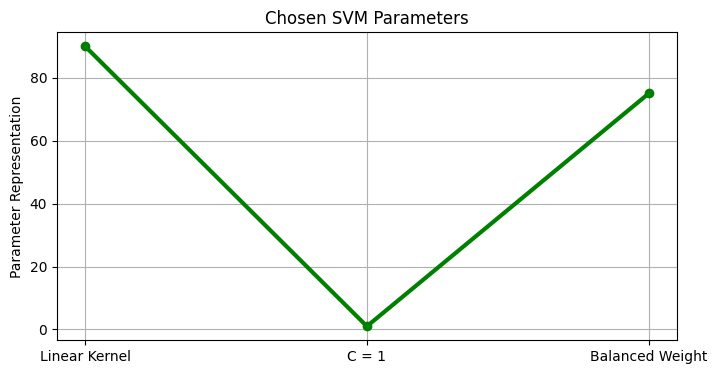

In [ ]:
parameters = [
    'Linear Kernel',
    'C = 1',
    'Balanced Weight'
]

values = [
    90,   # visual representation for kernel
    1,
    75    # visual representation for balanced weight
]

plt.figure(figsize=(8,4))

plt.plot(parameters, values, marker='o', linewidth=3, color="green")

plt.title("Chosen SVM Parameters")
plt.ylabel("Parameter Representation")
plt.grid(True)

plt.show()

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='linear',          # Linear kernel — finds a straight hyperplane to separate classes
    C=1,                      # Regularization strength — lower value = simpler boundary, less overfitting
    class_weight='balanced',  # Handles class imbalance
    random_state=42           # Ensures reproducibility
)

scores = cross_val_score(svm, X_train, y_train, cv=skf)
print('CV Acc: ', scores.mean())

svm.fit(X_train, y_train)
print("SVM model trained.")

CV Acc:  0.8474999999999999
SVM model trained.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = svm.predict(X_test)

print("Training Accuracy:", svm.score(X_train, y_train))
print("Testing Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Training Accuracy: 0.8575
Testing Accuracy : 0.825

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85        97
           1       0.70      0.75      0.73        60
           2       0.93      0.91      0.92        43

    accuracy                           0.82       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.82      0.83       200


Confusion Matrix:
 [[81 16  0]
 [12 45  3]
 [ 1  3 39]]


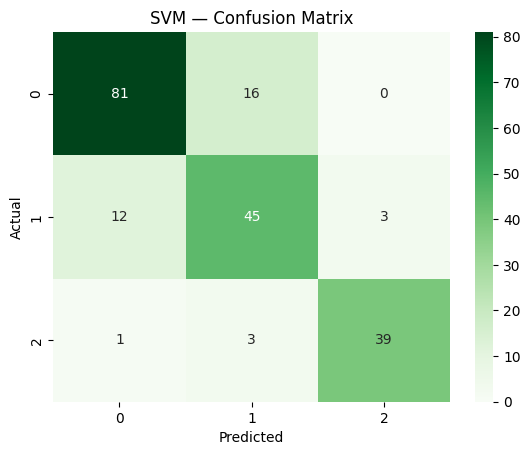

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Greens', fmt='d',
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title("SVM — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()